# Milestone 1 (v0.2) — Structural Encoding: Admittance-Weighted Random Walks

In [1]:
import sys, json, time, warnings
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
import networkx as nx

warnings.filterwarnings("ignore")
ROOT = Path.cwd()
sys.path.insert(0, str(ROOT))

from gridfm import dataset as ds
from gridfm import encoding as enc

PROC_DIR = ROOT / "data" / "processed"
FIG_DIR = ROOT / "results" / "figures" / "v02_m1"
STATS_DIR = ROOT / "results" / "v02_m1_stats"
FIG_DIR.mkdir(parents=True, exist_ok=True)
STATS_DIR.mkdir(parents=True, exist_ok=True)

GRIDS = ["case24", "case30", "case118", "case39"]
GRID_COLOR = {"case24": "#4269D0", "case30": "#EFB118",
              "case118": "#FF725C", "case39": "#6CC5B0"}
torch.manual_seed(42); np.random.seed(42)

# one intact (no outage) training scenario per grid, for the structural studies
intact = {}
for g in GRIDS:
    for d in ds.load_processed(PROC_DIR, g, "train"):
        if d.n_removed == 0:
            intact[g] = d
            break
for g, d in intact.items():
    print(f"{g:8s} buses {d.num_nodes:4d}  branches {d.edge_index.shape[1] // 2:4d}"
          f"  (scenario {int(d.scenario)})")

case24   buses   24  branches   38  (scenario 0)
case30   buses   30  branches   41  (scenario 2000)
case118  buses  118  branches  186  (scenario 4000)
case39   buses   39  branches   46  (scenario 6000)


## Step 1 — From admittances to a walk

case24   max |row sum - 1| = 6.0e-08   (valid probabilities)
case30   max |row sum - 1| = 1.2e-07   (valid probabilities)
case118  max |row sum - 1| = 1.2e-07   (valid probabilities)
case39   max |row sum - 1| = 1.2e-07   (valid probabilities)


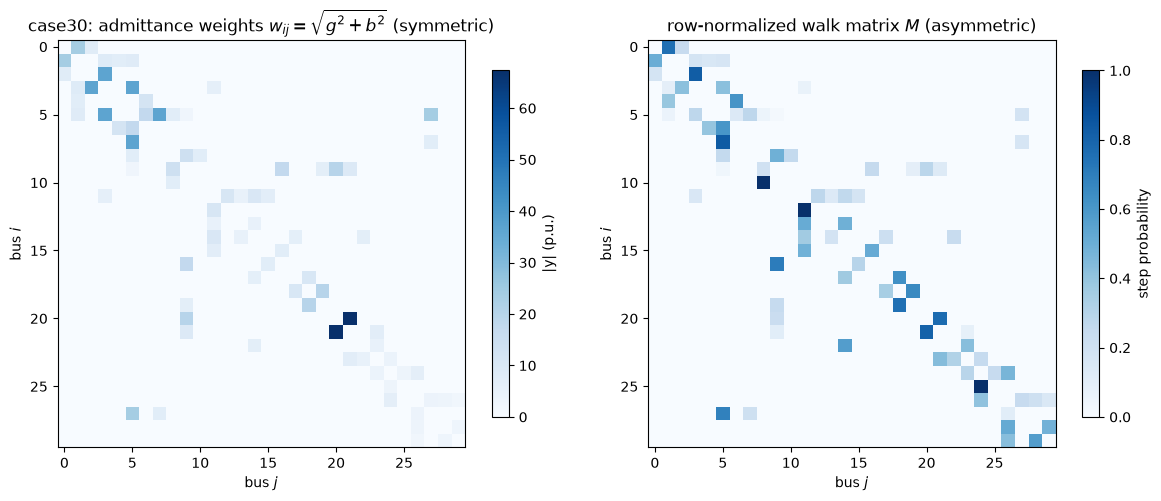


most asymmetric branch 24-25: leaving bus 25 the walker takes it with p=1.00 (this line is all bus 25 has), while leaving bus 24 only with p=0.24 (one path among many at a stiff bus)


In [2]:
d30 = intact["case30"]
W = torch.zeros(d30.num_nodes, d30.num_nodes)
w = torch.sqrt(d30.edge_attr[:, 0] ** 2 + d30.edge_attr[:, 1] ** 2)
W.index_put_((d30.edge_index[0], d30.edge_index[1]), w, accumulate=True)
M = enc.transition_matrix(d30.edge_index, d30.edge_attr, d30.num_nodes)

# validity checks on every grid
for g, d in intact.items():
    Mg = enc.transition_matrix(d.edge_index, d.edge_attr, d.num_nodes)
    row_err = float((Mg.sum(1) - 1.0).abs().max())
    assert row_err < 1e-5, (g, row_err)
    assert float(Mg.min()) >= 0.0
    print(f"{g:8s} max |row sum - 1| = {row_err:.1e}   (valid probabilities)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
im0 = axes[0].imshow(W.numpy(), cmap="Blues")
axes[0].set(title="case30: admittance weights $w_{ij}=\\sqrt{g^2+b^2}$ (symmetric)",
            xlabel="bus $j$", ylabel="bus $i$")
fig.colorbar(im0, ax=axes[0], label="|y| (p.u.)", shrink=0.85)
im1 = axes[1].imshow(M.numpy(), cmap="Blues")
axes[1].set(title="row-normalized walk matrix $M$ (asymmetric)",
            xlabel="bus $j$", ylabel="bus $i$")
fig.colorbar(im1, ax=axes[1], label="step probability", shrink=0.85)
fig.tight_layout(); fig.savefig(FIG_DIR / "f1_transition_matrix.png", bbox_inches="tight", dpi=150)
plt.show()

# the asymmetry in words, with the most extreme branch
asym = (M - M.T).abs()
i, j = np.unravel_index(int(asym.argmax()), asym.shape)
lo, hi = (i, j) if M[i, j] < M[j, i] else (j, i)
print(f"\nmost asymmetric branch {i}-{j}: leaving bus {hi} the walker takes it with "
      f"p={float(M[hi, lo]):.2f} (this line is all bus {hi} has), while leaving bus "
      f"{lo} only with p={float(M[lo, hi]):.2f} (one path among many at a stiff bus)")

## Step 2 — What the fingerprint sees

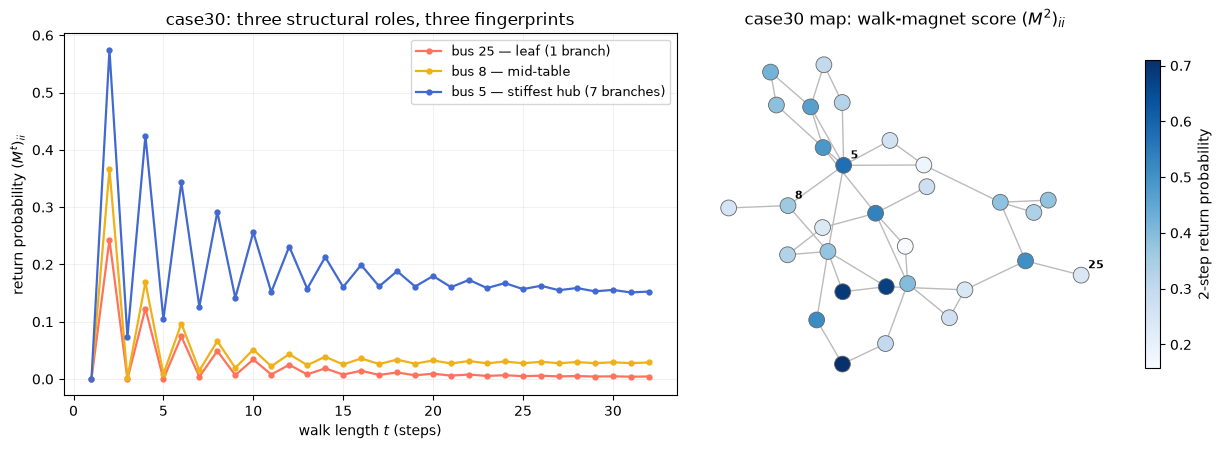

leaf bus 25: 2-step return 0.24   hub bus 5: 2-step return 0.57
hub  bus  5: stationary share pi = 0.130   return prob at t=31/32 = 0.152
mid  bus  8: stationary share pi = 0.028   return prob at t=31/32 = 0.028
leaf bus 25: stationary share pi = 0.003   return prob at t=31/32 = 0.004


In [3]:
K_SHOW = 32
pe30 = enc.rwpe(d30.edge_index, d30.edge_attr, d30.num_nodes, k=K_SHOW).numpy()
stiff = W.sum(1).numpy()                      # total admittance at each bus
deg = (W > 0).sum(1).numpy()                  # number of branches at each bus
hub = int(stiff.argmax())
leaf = int(np.where(deg == 1)[0][stiff[deg == 1].argmin()]) if (deg == 1).any() else int(stiff.argmin())
mid = int(np.argsort(stiff)[len(stiff) // 2])

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6), gridspec_kw={"width_ratios": [1.15, 1]})
t = np.arange(1, K_SHOW + 1)
for b, c, lab in [(leaf, "#FF725C", f"bus {leaf} — leaf (1 branch)"),
                  (mid,  "#EFB118", f"bus {mid} — mid-table"),
                  (hub,  "#4269D0", f"bus {hub} — stiffest hub ({int(deg[hub])} branches)")]:
    axes[0].plot(t, pe30[b], marker="o", ms=3.5, lw=1.6, color=c, label=lab)
axes[0].set(xlabel="walk length $t$ (steps)", ylabel="return probability $(M^t)_{ii}$",
            title="case30: three structural roles, three fingerprints")
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.25, lw=0.5)

G = nx.Graph()
G.add_nodes_from(range(d30.num_nodes))
eij = d30.edge_index.numpy()
G.add_edges_from({tuple(sorted((int(a), int(b)))) for a, b in zip(eij[0], eij[1])})
pos = nx.spring_layout(G, seed=42, weight=None)
nodes = nx.draw_networkx_nodes(G, pos, ax=axes[1], node_size=130,
                               node_color=pe30[:, 1], cmap="Blues",
                               edgecolors="#666666", linewidths=0.6)
nx.draw_networkx_edges(G, pos, ax=axes[1], edge_color="#BBBBBB", width=1.0)
for b in (leaf, mid, hub):
    axes[1].annotate(str(b), pos[b], fontsize=8, fontweight="bold",
                     xytext=(5, 5), textcoords="offset points")
fig.colorbar(nodes, ax=axes[1], label="2-step return probability", shrink=0.85)
axes[1].set_title("case30 map: walk-magnet score $(M^2)_{ii}$")
axes[1].axis("off")
fig.tight_layout(); fig.savefig(FIG_DIR / "f2_return_probability.png", bbox_inches="tight", dpi=150)
plt.show()
print(f"leaf bus {leaf}: 2-step return {pe30[leaf, 1]:.2f}   "
      f"hub bus {hub}: 2-step return {pe30[hub, 1]:.2f}")

# the long-run plateau is the stationary (stiffness) share pi_i = s_i / sum(s):
pi = stiff / stiff.sum()
tail = pe30[:, -2:].mean(axis=1)          # average of t=31,32 damps the odd/even sawtooth
for b, name in [(hub, "hub"), (mid, "mid"), (leaf, "leaf")]:
    print(f"{name:4s} bus {b:2d}: stationary share pi = {pi[b]:.3f}   "
          f"return prob at t=31/32 = {tail[b]:.3f}")

## Step 3 — Choosing $k$

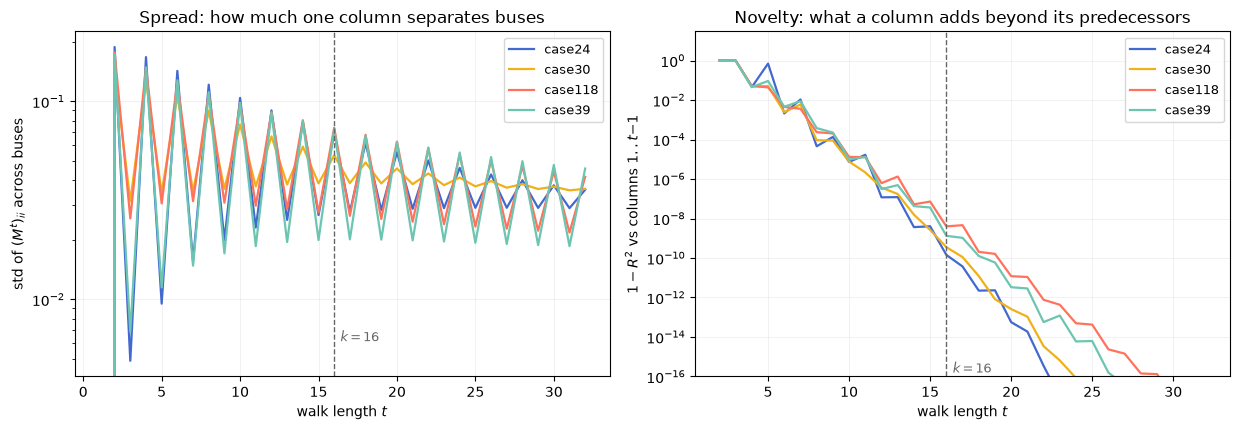

case24   max novelty of any column beyond t=16: 0.000
case30   max novelty of any column beyond t=16: 0.000
case118  max novelty of any column beyond t=16: 0.000
case39   max novelty of any column beyond t=16: 0.000


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
novelty_beyond_16 = {}
for g in GRIDS:
    d = intact[g]
    pe = enc.rwpe(d.edge_index, d.edge_attr.double(), d.num_nodes, k=K_SHOW).numpy()
    spread = pe.std(axis=0)
    nov = [np.nan]  # column 1 has no predecessors
    for tt in range(1, K_SHOW):
        Xp = np.column_stack([pe[:, :tt], np.ones(len(pe))])
        y = pe[:, tt]
        resid = y - Xp @ np.linalg.lstsq(Xp, y, rcond=None)[0]
        nov.append(0.0 if y.var() < 1e-18 else float(resid.var() / y.var()))
    nov = np.array(nov)
    axes[0].plot(t, spread, lw=1.6, color=GRID_COLOR[g], label=g)
    axes[1].plot(t, nov, lw=1.6, color=GRID_COLOR[g], label=g)
    novelty_beyond_16[g] = float(np.nanmax(nov[16:]))
axes[0].set(xlabel="walk length $t$", ylabel="std of $(M^t)_{ii}$ across buses",
            title="Spread: how much one column separates buses", yscale="log")
axes[1].set(xlabel="walk length $t$", ylabel="$1 - R^2$ vs columns $1..t{-}1$",
            title="Novelty: what a column adds beyond its predecessors", yscale="log",
            ylim=(1e-16, 30))
for ax in axes:
    ax.axvline(16, color="#666666", lw=1.0, ls="--")
    ax.text(16.4, ax.get_ylim()[0] * 1.5, "$k=16$", fontsize=9, color="#666666")
    ax.grid(alpha=0.25, lw=0.5); ax.legend(fontsize=9)
fig.tight_layout(); fig.savefig(FIG_DIR / "f3_choosing_k.png", bbox_inches="tight", dpi=150)
plt.show()
for g, v in novelty_beyond_16.items():
    print(f"{g:8s} max novelty of any column beyond t=16: {v:.3f}")

## Step 4 — Two properties the model will rely on

(a) Invariance to the baseMVA normalization
(b) Locality of topology sensitivity.

(a) case118: max |RWPE(y) - RWPE(7.31*y)| = 2.98e-07


(b) case30 group 500: scenarios 2000 (intact) vs 2001 (2 outage(s)), lines out: [(9, 20), (18, 19)]


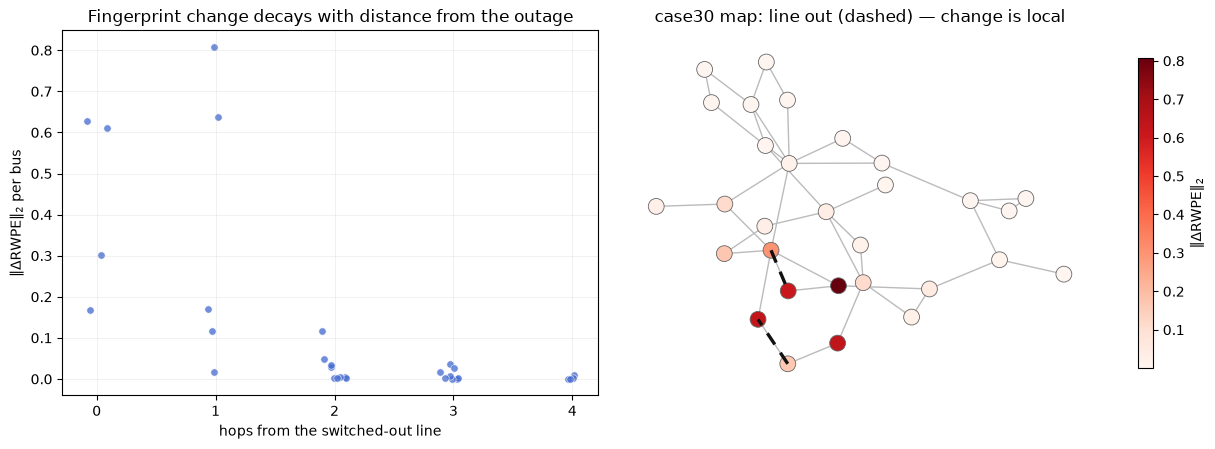

mean ||dRWPE||: <=1 hop from outage 0.384   >=4 hops 0.0026   ratio 150x


In [5]:
# (a) invariance under global admittance rescaling
d = intact["case118"]
pe_a = enc.rwpe(d.edge_index, d.edge_attr, d.num_nodes)
pe_b = enc.rwpe(d.edge_index, d.edge_attr * 7.31, d.num_nodes)   # arbitrary rescale
inv_err = float((pe_a - pe_b).abs().max())
print(f"(a) case118: max |RWPE(y) - RWPE(7.31*y)| = {inv_err:.2e}")
assert inv_err < 1e-5

# (b) locality: find an intact/perturbed pair of the same load scenario whose
# edge sets differ (i.e. the outage removed a line, not a generator)
train30 = ds.load_processed(PROC_DIR, "case30", "train")
by_group = {}
for dd in train30:
    by_group.setdefault(int(dd.group), []).append(dd)
pair, removed_edges = None, None
for grp, lst in sorted(by_group.items()):
    base = [dd for dd in lst if dd.n_removed == 0]
    pert = [dd for dd in lst if dd.n_removed > 0]
    if not (base and pert):
        continue
    e0 = {tuple(sorted(e)) for e in base[0].edge_index.T.tolist()}
    for pp in pert:
        e1 = {tuple(sorted(e)) for e in pp.edge_index.T.tolist()}
        if e0 - e1:
            pair, removed_edges = (base[0], pp), sorted(e0 - e1)
            break
    if pair:
        break
b0, b1 = pair
print(f"(b) case30 group {int(b0.group)}: scenarios {int(b0.scenario)} (intact) vs "
      f"{int(b1.scenario)} ({int(b1.n_removed)} outage(s)), lines out: {removed_edges}")

pe0 = enc.rwpe(b0.edge_index, b0.edge_attr, b0.num_nodes).numpy()
pe1 = enc.rwpe(b1.edge_index, b1.edge_attr, b1.num_nodes).numpy()
delta = np.linalg.norm(pe1 - pe0, axis=1)

# hop distance from the outage endpoints, on the intact graph
ends = sorted({b for e in removed_edges for b in e})
hop = {n: min(nx.shortest_path_length(G, source=en, target=n) for en in ends)
       for n in G.nodes}   # G is the intact case30 graph from Step 2
hops = np.array([hop[i] for i in range(b0.num_nodes)])

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6), gridspec_kw={"width_ratios": [1, 1.15]})
axes[0].scatter(hops + 0.06 * np.random.randn(len(hops)), delta, s=28,
                color="#4269D0", alpha=0.75, edgecolors="white", linewidths=0.5)
axes[0].set(xlabel="hops from the switched-out line", ylabel="$\\|\\Delta$RWPE$\\|_2$ per bus",
            title="Fingerprint change decays with distance from the outage")
axes[0].grid(alpha=0.25, lw=0.5)

nodes = nx.draw_networkx_nodes(G, pos, ax=axes[1], node_size=130, node_color=delta,
                               cmap="Reds", edgecolors="#666666", linewidths=0.6)
nx.draw_networkx_edges(G, pos, ax=axes[1], edge_color="#BBBBBB", width=1.0)
for (u, v) in removed_edges:
    axes[1].plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]],
                 color="#111111", lw=2.4, ls=(0, (4, 3)))
fig.colorbar(nodes, ax=axes[1], label="$\\|\\Delta$RWPE$\\|_2$", shrink=0.85)
axes[1].set_title("case30 map: line out (dashed) — change is local")
axes[1].axis("off")
fig.tight_layout(); fig.savefig(FIG_DIR / "f4_perturbation_sensitivity.png", bbox_inches="tight", dpi=150)
plt.show()
near = float(delta[hops <= 1].mean()); far = float(delta[hops >= 4].mean()) if (hops >= 4).any() else float("nan")
print(f"mean ||dRWPE||: <=1 hop from outage {near:.3f}   >=4 hops {far:.4f}   ratio {near / far:.0f}x")

## Step 5 — The whole dataset: cost and a look at 6,700 grids' worth of fingerprints

RWPE (k=16) for 6700 graphs / 366873 bus-vectors in 6.1 s  (0.91 ms per graph)


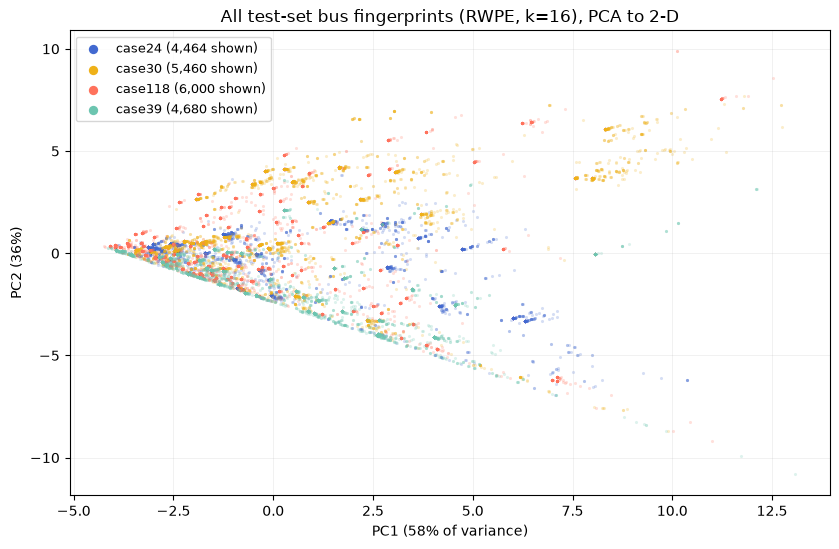

{
  "k": 16,
  "n_graphs": 6700,
  "n_bus_vectors": 366873,
  "total_seconds": 6.09,
  "ms_per_graph": 0.909,
  "invariance_max_abs_err": 2.980232238769531e-07,
  "outage_delta_near_mean": 0.3843603730201721,
  "outage_delta_far_mean": 0.0025626132264733315,
  "novelty_beyond_16": {
    "case24": 3.7197040900967826e-11,
    "case30": 1.1120064098518901e-10,
    "case118": 4.583955219573038e-09,
    "case39": 1.0465244139350192e-09
  },
  "pca_explained_variance_pc1_pc2": [
    0.5796493887901306,
    0.3613573908805847
  ]
}


In [6]:
t0 = time.time()
n_graphs, n_buses = 0, 0
all_pe, all_grid = [], []
for g in GRIDS:
    for split in ["train", "val", "test"]:
        graphs = ds.load_processed(PROC_DIR, g, split)
        enc.add_rwpe(graphs)
        n_graphs += len(graphs)
        n_buses += sum(int(d.num_nodes) for d in graphs)
        if split == "test":                      # keep test fingerprints for the PCA
            for d in graphs:
                all_pe.append(d.rwpe.numpy())
                all_grid += [g] * d.num_nodes
elapsed = time.time() - t0
print(f"RWPE (k={enc.K_STEPS}) for {n_graphs} graphs / {n_buses} bus-vectors "
      f"in {elapsed:.1f} s  ({1000 * elapsed / n_graphs:.2f} ms per graph)")

X = np.vstack(all_pe)
mu, sd = X.mean(0), X.std(0)
Xz = (X - mu) / np.where(sd < 1e-12, 1.0, sd)    # column 1 is all-zero -> left as 0
U, S, Vt = np.linalg.svd(Xz - Xz.mean(0), full_matrices=False)
pc = (Xz - Xz.mean(0)) @ Vt[:2].T
evr = (S ** 2 / (S ** 2).sum())[:2]

fig, ax = plt.subplots(figsize=(8.5, 5.6))
rng = np.random.RandomState(42)
all_grid = np.array(all_grid)
for g in GRIDS:
    idx = np.where(all_grid == g)[0]
    idx = rng.choice(idx, size=min(6000, len(idx)), replace=False)
    ax.scatter(pc[idx, 0], pc[idx, 1], s=5, alpha=0.22, lw=0,
               color=GRID_COLOR[g], label=f"{g} ({len(idx):,} shown)")
leg = ax.legend(fontsize=9, markerscale=3)
for lh in leg.legend_handles:
    lh.set_alpha(1.0)
ax.set(xlabel=f"PC1 ({evr[0]:.0%} of variance)", ylabel=f"PC2 ({evr[1]:.0%})",
       title=f"All test-set bus fingerprints (RWPE, k={enc.K_STEPS}), PCA to 2-D")
ax.grid(alpha=0.25, lw=0.5)
fig.tight_layout(); fig.savefig(FIG_DIR / "f5_dataset_fingerprints.png", bbox_inches="tight", dpi=150)
plt.show()

stats = {"k": int(enc.K_STEPS), "n_graphs": n_graphs, "n_bus_vectors": n_buses,
         "total_seconds": round(elapsed, 2), "ms_per_graph": round(1000 * elapsed / n_graphs, 3),
         "invariance_max_abs_err": inv_err,
         "outage_delta_near_mean": near, "outage_delta_far_mean": far,
         "novelty_beyond_16": novelty_beyond_16,
         "pca_explained_variance_pc1_pc2": [float(evr[0]), float(evr[1])]}
with open(STATS_DIR / "rwpe_stats.json", "w") as f:
    json.dump(stats, f, indent=2)
print(json.dumps(stats, indent=2))